In [ ]:
"""
AGENTIC RAG IN LANGGRAPH - COMPREHENSIVE SUMMARY

1. OVERVIEW
Agentic RAG (Retrieval-Augmented Generation) in LangGraph represents an advanced approach to building 
intelligent information retrieval and generation systems. It combines the power of retrieval-based 
methods with generative AI capabilities, orchestrated through LangGraph's workflow management.

2. KEY COMPONENTS
- Agents: Autonomous entities that can make decisions and execute actions
- RAG Pipeline: Retrieval system + Language model for generation
- LangGraph: Workflow orchestration framework for complex AI applications
- Vector Stores: Embeddings-based knowledge repositories
- Tools: External APIs, databases, and custom functions

3. ARCHITECTURE BENEFITS
- Dynamic Decision Making: Agents can choose when and how to retrieve information
- Multi-step Reasoning: Complex queries broken down into manageable steps
- Adaptive Retrieval: Context-aware information fetching based on conversation flow
- Tool Integration: Seamless connection to external data sources and APIs

4. CORE FEATURES
- State Management: Persistent conversation and context tracking
- Conditional Logic: Branching workflows based on user input and system state
- Error Handling: Robust fallback mechanisms and retry logic
- Scalability: Distributed processing and parallel execution capabilities

5. USE CASES
- Customer Support: Intelligent help desk with dynamic knowledge retrieval
- Research Assistance: Academic and professional research with source verification
- Technical Documentation: Interactive manuals with contextual information
- Business Intelligence: Data-driven insights with natural language queries

6. IMPLEMENTATION ADVANTAGES
- Flexibility: Easily customizable workflows for specific domains
- Transparency: Clear visibility into agent decision-making processes
- Reliability: Built-in monitoring and debugging capabilities
- Integration: Compatible with popular ML/AI frameworks and databases

This approach represents the evolution from static RAG systems to dynamic, intelligent 
information processing agents capable of complex reasoning and decision-making.

"""

In [159]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_API_KEY")
os.environ["OPENAI_ENDPOINT"] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ["OPENAI_API_VERSION"] = "2024-12-01-preview"
os.environ["OPENAI_DEPLOYMENT_NAME"] = "gpt-4o"
os.environ["OPENAI_MODEL"] = "gpt-4o"

open_api_key = os.getenv("AZURE_OPENAI_API_KEY")
if os.getenv("AZURE_OPENAI_API_KEY"):
    print(f"Azure Open API Key loaded: {open_api_key[:10]}...{open_api_key[-4:]}")
    print(f"Model: {os.getenv('OPENAI_MODEL')}")
    os.environ["OPENAI_API_KEY"] = open_api_key
else:
    print("Azure API Key not found in environment variables")
    print("Available environment variables with 'Azure':", [k for k in os.environ.keys() if 'Azure' in k.upper()])



Azure Open API Key loaded: 1Sttw3VbMy...EzVq
Model: gpt-4o


In [160]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import AzureOpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

langgraph_urls = [
    "https://langchain-ai.github.io/langgraph/#get-started",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/agents/overview/"
]

In [161]:
docs = [WebBaseLoader(url).load() for url in langgraph_urls]
docs


[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/#get-started', 'title': 'LangGraph', 'description': 'Build reliable, stateful AI systems, without giving up control', 'language': 'en'}, page_content='\n\n\n\n\n\n\n\n\n\n\nLangGraph\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n          Skip to content\n        \n\n\n\n\n\n\n\nWe are growing and hiring for multiple roles for LangChain, LangGraph and LangSmith.  Join our team!\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n            LangGraph\n          \n\n\n\n            \n              LangGraph\n            \n          \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n            Initializing search\n          \n\n\n\n\n\n\n\n\n\n\n\n\n    GitHub\n  \n\n\n\n\n\n\n\n\n\n\n          \n  \n  \n    \n  \n  Get started\n\n        \n\n\n\n          \n  \n  \n    \n  \n  Guides\n\n        \n\n\n\n          \n  \n  \n    \n  \n  Reference\n\n        \n\n\n\n          \n  \n  \n    \n  \

In [162]:
doc_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits = text_splitter.split_documents(doc_list)
print(f"Number of document splits: {len(doc_splits)}")
print(doc_splits[0].page_content[:500])  


Number of document splits: 60
LangGraph



























          Skip to content
        







We are growing and hiring for multiple roles for LangChain, LangGraph and LangSmith.  Join our team!

















            LangGraph
          



            
              LangGraph
            
          








































            Initializing search
          












    GitHub
  










          
  
  
    
  
  Get started

        



          
  
  
    
  
  Guides




In [163]:
# add text to vector db
os.environ["OPENAI_DEPLOYMENT_NAME"] = "text-embedding-3-large"
os.environ["OPENAI_MODEL"] = "text-embedding-3-large"

embeddings_langgraph = AzureOpenAIEmbeddings(
	azure_deployment=os.environ["OPENAI_DEPLOYMENT_NAME"],
	openai_api_version=os.environ["OPENAI_API_VERSION"],
	azure_endpoint=os.environ["OPENAI_ENDPOINT"],
	openai_api_key=os.environ["OPENAI_API_KEY"]
)

embeddings_langchain= AzureOpenAIEmbeddings(
	azure_deployment=os.environ["OPENAI_DEPLOYMENT_NAME"],
	openai_api_version=os.environ["OPENAI_API_VERSION"],
	azure_endpoint=os.environ["OPENAI_ENDPOINT"],
	openai_api_key=os.environ["OPENAI_API_KEY"]
)


In [172]:
from langchain_community.vectorstores import FAISS

vector_store_langgraph = FAISS.from_documents(doc_splits, embeddings_langgraph)
vector_store_langgraph

retriever_langgraph = vector_store_langgraph.as_retriever()
retriever_langgraph

VectorStoreRetriever(tags=['FAISS', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x749b538b3c80>, search_kwargs={})

In [173]:
retriever_langgraph.get_relevant_documents("What is LangGraph?")[:3]
retriever_langgraph.get_relevant_documents("What is LangGraph?")[0].page_content


'LangGraph’s ecosystem¶\nWhile LangGraph can be used standalone, it also integrates seamlessly with any LangChain product, giving developers a full suite of tools for building agents. To improve your LLM application development, pair LangGraph with:\n\nLangSmith — Helpful for agent evals and observability. Debug poor-performing LLM app runs, evaluate agent trajectories, gain visibility in production, and improve performance over time.\nLangGraph Platform — Deploy and scale agents effortlessly with a purpose-built deployment platform for long running, stateful workflows. Discover, reuse, configure, and share agents across teams — and iterate quickly with visual prototyping in LangGraph Studio.\nLangChain – Provides integrations and composable components to streamline LLM application development.\n\n\nNote\nLooking for the JS version of LangGraph? See the JS repo and the JS docs.\n\nAdditional resources¶'

In [174]:
retriever_langgraph.invoke("what is LangGraph?")

[Document(id='a728756c-8460-477b-b08c-3b541843a080', metadata={'source': 'https://langchain-ai.github.io/langgraph/#get-started', 'title': 'LangGraph', 'description': 'Build reliable, stateful AI systems, without giving up control', 'language': 'en'}, page_content='LangGraph’s ecosystem¶\nWhile LangGraph can be used standalone, it also integrates seamlessly with any LangChain product, giving developers a full suite of tools for building agents. To improve your LLM application development, pair LangGraph with:\n\nLangSmith — Helpful for agent evals and observability. Debug poor-performing LLM app runs, evaluate agent trajectories, gain visibility in production, and improve performance over time.\nLangGraph Platform — Deploy and scale agents effortlessly with a purpose-built deployment platform for long running, stateful workflows. Discover, reuse, configure, and share agents across teams — and iterate quickly with visual prototyping in LangGraph Studio.\nLangChain – Provides integration

In [189]:
# convert retriever to tools
from langchain.tools.retriever import create_retriever_tool

retriever_tool_langgraph = create_retriever_tool(
    retriever=retriever_langgraph,
    name="retriever_tool_langgraph",
    description="A tool to retrieve information about LangGraph from the vector store."
)
retriever_tool_langgraph

Tool(name='retriever_tool_langgraph', description='A tool to retrieve information about LangGraph from the vector store.', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x749b50be5080>, retriever=VectorStoreRetriever(tags=['FAISS', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x749b538b3c80>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=functools.partial(<function _aget_relevant_documents at 0x749b50be6840>, retriever=VectorStoreRetriever(tags=['FAISS', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x749b538b3c80>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, templat

In [190]:
#langchain blogs - vector db

langchain_urls = [
    "https://python.langchain.com/docs/introduction/",
    "https://python.langchain.com/docs/how_to/tool_calling/",
    "https://python.langchain.com/docs/concepts/prompt_templates/"
]

In [191]:
docs = [WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/introduction/', 'title': 'Introduction | 🦜️🔗 LangChain', 'description': 'LangChain is a framework for developing applications powered by large language models (LLMs).', 'language': 'en'}, page_content='\n\n\n\n\nIntroduction | 🦜️🔗 LangChain\n\n\n\n\n\n\nSkip to main contentOur Building Ambient Agents with LangGraph course is now available on LangChain Academy!IntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1💬SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat models and prompt templatesBuild a ChatbotBuild a Retrieval Augmented Generation (RAG) App: Part 2Build an Extraction ChainBuild an AgentTaggingBuild a Retrieval Augmented Generation (RAG) App: Part 1Build a semantic search engineBuild a Question/Answering system over SQL dataSummarize TextHow-to guidesHow-to

In [192]:
doc_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits = text_splitter.split_documents(doc_list)
print(f"Number of document splits: {len(doc_splits)}")
print(doc_splits[0].page_content[:500])  

Number of document splits: 54
Introduction | 🦜️🔗 LangChain


In [193]:
from langchain_community.vectorstores import FAISS

vector_store_langchain = FAISS.from_documents(doc_splits, embeddings_langchain)
retriever_langchain = vector_store_langchain.as_retriever()
retriever_langchain

VectorStoreRetriever(tags=['FAISS', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x749b502d1970>, search_kwargs={})

In [194]:
# convert retriever to tools
from langchain.tools.retriever import create_retriever_tool

retriever_tool_langchain = create_retriever_tool(
    retriever=retriever_langchain,
    name="retriever_tool_langchain",
    description="A tool to retrieve information about LangGraph from the vector store."
)
retriever_tool_langchain

Tool(name='retriever_tool_langchain', description='A tool to retrieve information about LangGraph from the vector store.', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x749b50be5080>, retriever=VectorStoreRetriever(tags=['FAISS', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x749b502d1970>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=functools.partial(<function _aget_relevant_documents at 0x749b50be6840>, retriever=VectorStoreRetriever(tags=['FAISS', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x749b502d1970>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, templat

In [195]:
tools = [retriever_tool_langgraph, retriever_tool_langchain]

In [196]:
from langchain_openai import AzureChatOpenAI
from langchain.schema import HumanMessage, SystemMessage

os.environ["OPENAI_DEPLOYMENT_NAME"] = "gpt-4o"
os.environ["OPENAI_MODEL"] = "gpt-4o"

# Create Azure ChatOpenAI instance
llm = AzureChatOpenAI(
    azure_deployment=os.getenv("OPENAI_DEPLOYMENT_NAME"),   
    api_version=os.getenv("OPENAI_API_VERSION"),            
    azure_endpoint=os.getenv("OPENAI_ENDPOINT"),           
    api_key=os.getenv("OPENAI_API_KEY")
)

print(f"Created Azure ChatOpenAI: {llm}")
llm.invoke("hello")

Created Azure ChatOpenAI: client=<openai.resources.chat.completions.completions.Completions object at 0x749b67cef2f0> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x749b67cef9e0> root_client=<openai.lib.azure.AzureOpenAI object at 0x749b67fe90d0> root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x749b67fe9340> model_kwargs={} openai_api_key=SecretStr('**********') disabled_params={'parallel_tool_calls': None} azure_endpoint='https://zama-roadmap-to-aiml.openai.azure.com/' deployment_name='gpt-4o' openai_api_version='2024-12-01-preview' openai_api_type='azure'


AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 8, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_ee1d74bde0', 'id': 'chatcmpl-BoZV54oHvl3UKl3KNz6TeAyJCHNi1', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 

In [197]:
# langgraph workflow
from typing import Annotated, Sequence, Literal
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, ToolMessage
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [198]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state.
    Given the question, it will decide whether to use the retriever tools or not.

    Args:
        state (AgentState): The current state of the agent, including messages.

    Returns:
        messages (dict): A dictionary containing the response message from the agent.
    """
    print(f"Invoking agent model with state: {state}")
    messages = state["messages"]
    print(f"Messages in state: {messages}")
    llm_with_tools = llm.bind_tools(tools)
    response = llm_with_tools.invoke(messages)
    print(f"Agent response: {response}")
    return {"messages": [response]}

def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether to generate a new response or rewrite the existing one based on the state.

    Args:
        state (AgentState): The current state of the agent, including messages.

    Returns:
        str: "generate" if a new response should be generated, "rewrite" if the existing response should be rewritten.
    """
    print(f"Grading documents in state: {state}")

    # data model
    class grade(BaseModel):
        """
        Binary score for relevance of the documents.
        """
        binary_score: str = Field(description="Relevenace score 'yes or 'no'")

    # invoke the model
    llm_with_tool = llm.with_structured_output(grade)

    #prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: \n\n {question} \n\n

        If the document contains keyword(s) or sematic meaning related to the question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question      
        """,
        input_variables=["context", "question"]
    )

    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    
    # Fix: Handle ToolMessage content properly
    if isinstance(last_message, ToolMessage):
        docs = last_message.content
    else:
        docs = str(last_message.content) if hasattr(last_message, 'content') else str(last_message)

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score
    print(f"Graded documents with score: {score}")

    if score == "yes":
        print("Documents are relevant, generating response.")
        return "generate"
    else:
        print("Documents are not relevant, rewriting response.")
        return "rewrite"


In [199]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [200]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    response = llm.invoke(msg)
    return {"messages": [response]}

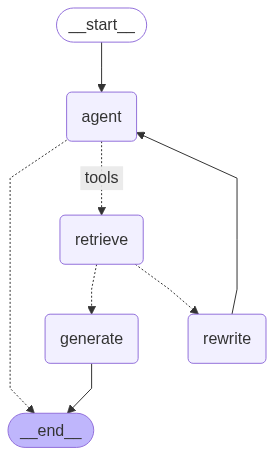

In [201]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool_langgraph, retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [203]:
graph.invoke({"messages": [HumanMessage(content="What is Langgraph?")]})

Invoking agent model with state: {'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='1b7a0199-ec1f-4b87-bfa3-7e5ac54edf13')]}
Messages in state: [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='1b7a0199-ec1f-4b87-bfa3-7e5ac54edf13')]
Agent response: content='' additional_kwargs={'tool_calls': [{'id': 'call_qsCbbE5GSQR0APRTdhhuLZwG', 'function': {'arguments': '{"query":"What is LangGraph?"}', 'name': 'retriever_tool_langgraph'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 106, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_ee1d74bde0', 'id': 'chatcmpl-BoZVg8fxHhJI4gglqQXrYPWzJfUXS', 's

{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='1b7a0199-ec1f-4b87-bfa3-7e5ac54edf13'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_qsCbbE5GSQR0APRTdhhuLZwG', 'function': {'arguments': '{"query":"What is LangGraph?"}', 'name': 'retriever_tool_langgraph'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 106, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_ee1d74bde0', 'id': 'chatcmpl-BoZVg8fxHhJI4gglqQXrYPWzJfUXS', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': 

In [204]:
graph.invoke({"messages": [HumanMessage(content="What is Langchain?")]})

Invoking agent model with state: {'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='2ddebb06-f979-4dd4-be1b-ed540a576f96')]}
Messages in state: [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='2ddebb06-f979-4dd4-be1b-ed540a576f96')]
Agent response: content='' additional_kwargs={'tool_calls': [{'id': 'call_KY4IBjmf54GbNPxE8diwZ5mP', 'function': {'arguments': '{"query":"What is LangChain?"}', 'name': 'retriever_tool_langchain'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 106, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_ee1d74bde0', 'id': 'chatcmpl-BoZVrFEc1PWRlYT7DRwxrlaN91069', 's

{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='2ddebb06-f979-4dd4-be1b-ed540a576f96'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_KY4IBjmf54GbNPxE8diwZ5mP', 'function': {'arguments': '{"query":"What is LangChain?"}', 'name': 'retriever_tool_langchain'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 106, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_ee1d74bde0', 'id': 'chatcmpl-BoZVrFEc1PWRlYT7DRwxrlaN91069', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': 

In [205]:
graph.invoke({"messages": [HumanMessage(content="What is MCP server?")]})

Invoking agent model with state: {'messages': [HumanMessage(content='What is MCP server?', additional_kwargs={}, response_metadata={}, id='af58f569-d3d7-4f2b-b9b5-0d8f19f9d3a1')]}
Messages in state: [HumanMessage(content='What is MCP server?', additional_kwargs={}, response_metadata={}, id='af58f569-d3d7-4f2b-b9b5-0d8f19f9d3a1')]
Agent response: content='' additional_kwargs={'tool_calls': [{'id': 'call_GDIOYyaFKZfiGwmJCqRBSK1Q', 'function': {'arguments': '{"query": "What is MCP server?"}', 'name': 'retriever_tool_langgraph'}, 'type': 'function'}, {'id': 'call_5t8LIY28D9zHePGvZR709tOA', 'function': {'arguments': '{"query": "What is MCP server?"}', 'name': 'retriever_tool_langchain'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 106, 'total_tokens': 167, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'

{'messages': [HumanMessage(content='What is MCP server?', additional_kwargs={}, response_metadata={}, id='af58f569-d3d7-4f2b-b9b5-0d8f19f9d3a1'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_GDIOYyaFKZfiGwmJCqRBSK1Q', 'function': {'arguments': '{"query": "What is MCP server?"}', 'name': 'retriever_tool_langgraph'}, 'type': 'function'}, {'id': 'call_5t8LIY28D9zHePGvZR709tOA', 'function': {'arguments': '{"query": "What is MCP server?"}', 'name': 'retriever_tool_langchain'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 106, 'total_tokens': 167, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_ee1d74bde0', 'id': 'chatcmpl-BoZW8Irv2f3z39ENN82AvUtlsSQAL', 'service_tier': None, 'pro